In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("fruits.csv")

# Standardize column names
df.columns = df.columns.str.lower()

df.head()

,fruit_id,fruit_type,size_cm,weight_g,color_intensity,ripeness_level,firmness,sweetness,defect_count,bruise_score,spot_score,defect_score,size_to_weight_ratio,grade
0,FR00001,Peach,5.98,141.19,0.40,0.08,0.91,0.18,0,0.05,0.60,0.14,4.24,Reject
1,FR00002,Orange,7.60,154.18,0.34,0.57,0.04,0.51,1,0.10,0.44,0.17,4.93,Local
2,FR00003,Pear,9.99,207.51,0.58,0.39,0.12,0.54,2,0.42,0.45,0.32,4.82,Reject
3,FR00004,Grapes,1.86,4.54,0.34,0.48,0.94,0.76,2,0.48,0.65,0.38,40.93,Local
4,FR00005,Peach,6.13,154.68,0.78,0.63,0.13,0.35,0,0.38,0.72,0.26,3.96,Local


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Dataset Shape: (10000, 14)

Columns:
 Index(['fruit_id', 'fruit_type', 'size_cm', 'weight_g', 'color_intensity',
       'ripeness_level', 'firmness', 'sweetness', 'defect_count',
       'bruise_score', 'spot_score', 'defect_score', 'size_to_weight_ratio',
       'grade'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fruit_id              10000 non-null  object 
 1   fruit_type            10000 non-null  object 
 2   size_cm               10000 non-null  float64
 3   weight_g              10000 non-null  float64
 4   color_intensity       10000 non-null  float64
 5   ripeness_level        10000 non-null  float64
 6   firmness              10000 non-null  float64
 7   sweetness             10000 non-null  float64
 8   defect_count          10000 non-null  int64  
 9   bruise_score          10000 non

In [5]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['size_cm', 'weight_g', 'color_intensity', 'ripeness_level', 'firmness', 'sweetness', 'defect_count', 'bruise_score', 'spot_score', 'defect_score', 'size_to_weight_ratio']
Categorical Columns: ['fruit_id', 'fruit_type', 'grade']


**Statistical Analysis**

In [6]:
print("===== MEAN =====")
print(df[num_cols].mean())

print("\n===== MEDIAN =====")
print(df[num_cols].median())

print("\n===== MODE =====")
print(df[num_cols].mode().iloc[0])

===== MEAN =====
size_cm                  10.075579
weight_g                649.621014
color_intensity           0.649254
ripeness_level            0.498067
firmness                  0.501517
sweetness                 0.501033
defect_count              1.284700
bruise_score              0.500135
spot_score                0.501577
defect_score              0.314594
size_to_weight_ratio     10.135260
dtype: float64

===== MEDIAN =====
size_cm                   8.400
weight_g                156.685
color_intensity           0.650
ripeness_level            0.500
firmness                  0.500
sweetness                 0.500
defect_count              1.000
bruise_score              0.500
spot_score                0.500
defect_score              0.310
size_to_weight_ratio      5.140
dtype: float64

===== MODE =====
size_cm                 7.17
weight_g                5.10
color_intensity         0.92
ripeness_level          0.22
firmness                0.32
sweetness               0.77
defe

In [7]:
print("===== STANDARD DEVIATION =====")
print(df[num_cols].std())

print("\n===== VARIANCE =====")
print(df[num_cols].var())

===== STANDARD DEVIATION =====
size_cm                    6.662874
weight_g                1505.014568
color_intensity            0.202500
ripeness_level             0.288564
firmness                   0.288167
sweetness                  0.286911
defect_count               1.139638
bruise_score               0.287827
spot_score                 0.289550
defect_score               0.118150
size_to_weight_ratio      11.729291
dtype: float64

===== VARIANCE =====
size_cm                 4.439388e+01
weight_g                2.265069e+06
color_intensity         4.100606e-02
ripeness_level          8.326902e-02
firmness                8.304021e-02
sweetness               8.231815e-02
defect_count            1.298776e+00
bruise_score            8.284422e-02
spot_score              8.383935e-02
defect_score            1.395941e-02
size_to_weight_ratio    1.375763e+02
dtype: float64


In [8]:
print("===== SKEWNESS =====")
print(df[num_cols].skew())

print("\n===== KURTOSIS =====")
print(df[num_cols].kurt())

===== SKEWNESS =====
size_cm                 1.218658
weight_g                2.715794
color_intensity         0.008746
ripeness_level         -0.000669
firmness               -0.005151
sweetness              -0.013887
defect_count            0.885354
bruise_score           -0.006133
spot_score             -0.011859
defect_score            0.069752
size_to_weight_ratio    2.107427
dtype: float64

===== KURTOSIS =====
size_cm                 0.884962
weight_g                5.681895
color_intensity        -1.201619
ripeness_level         -1.209982
firmness               -1.191471
sweetness              -1.199550
defect_count            0.805422
bruise_score           -1.198095
spot_score             -1.205642
defect_score           -0.400931
size_to_weight_ratio    4.186782
dtype: float64


In [9]:
stats_summary = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Std Dev": df[num_cols].std(),
    "Variance": df[num_cols].var(),
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurt()
})

stats_summary

,Mean,Median,Mode,Std Dev,Variance,Skewness,Kurtosis
size_cm,10.075579,8.400,7.17,6.662874,4.439388e+01,1.218658,0.884962
weight_g,649.621014,156.685,5.10,1505.014568,2.265069e+06,2.715794,5.681895
color_intensity,0.649254,0.650,0.92,0.202500,4.100606e-02,0.008746,-1.201619
ripeness_level,0.498067,0.500,0.22,0.288564,8.326902e-02,-0.000669,-1.209982
firmness,0.501517,0.500,0.32,0.288167,8.304021e-02,-0.005151,-1.191471
sweetness,0.501033,0.500,0.77,0.286911,8.231815e-02,-0.013887,-1.199550
defect_count,1.284700,1.000,1.00,1.139638,1.298776e+00,0.885354,0.805422
bruise_score,0.500135,0.500,0.53,0.287827,8.284422e-02,-0.006133,-1.198095
spot_score,0.501577,0.500,0.32,0.289550,8.383935e-02,-0.011859,-1.205642
defect_score,0.314594,0.310,0.31,0.118150,1.395941e-02,0.069752,-0.400931


In [10]:
for col in num_cols:
    skew = df[col].skew()
    kurt = df[col].kurt()

    print(f"\nFeature: {col}")
    print(f"Skewness: {skew:.2f}")
    print(f"Kurtosis: {kurt:.2f}")

    if skew > 1:
        print("Interpretation: Highly right-skewed distribution.")
    elif skew < -1:
        print("Interpretation: Highly left-skewed distribution.")
    else:
        print("Interpretation: Approximately symmetric distribution.")

    if kurt > 3:
        print("Interpretation: Heavy tails (more extreme values).")
    else:
        print("Interpretation: Normal/light tails distribution.")


Feature: size_cm
Skewness: 1.22
Kurtosis: 0.88
Interpretation: Highly right-skewed distribution.
Interpretation: Normal/light tails distribution.

Feature: weight_g
Skewness: 2.72
Kurtosis: 5.68
Interpretation: Highly right-skewed distribution.
Interpretation: Heavy tails (more extreme values).

Feature: color_intensity
Skewness: 0.01
Kurtosis: -1.20
Interpretation: Approximately symmetric distribution.
Interpretation: Normal/light tails distribution.

Feature: ripeness_level
Skewness: -0.00
Kurtosis: -1.21
Interpretation: Approximately symmetric distribution.
Interpretation: Normal/light tails distribution.

Feature: firmness
Skewness: -0.01
Kurtosis: -1.19
Interpretation: Approximately symmetric distribution.
Interpretation: Normal/light tails distribution.

Feature: sweetness
Skewness: -0.01
Kurtosis: -1.20
Interpretation: Approximately symmetric distribution.
Interpretation: Normal/light tails distribution.

Feature: defect_count
Skewness: 0.89
Kurtosis: 0.81
Interpretation: Appro

**Visualizations**

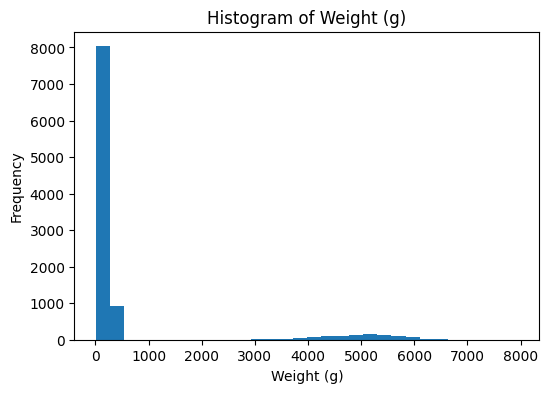

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["weight_g"], bins=30)
plt.title("Histogram of Weight (g)")
plt.xlabel("Weight (g)")
plt.ylabel("Frequency")
plt.show()

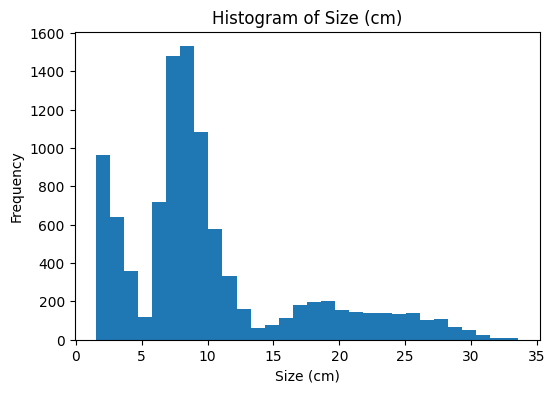

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["size_cm"], bins=30)
plt.title("Histogram of Size (cm)")
plt.xlabel("Size (cm)")
plt.ylabel("Frequency")
plt.show()

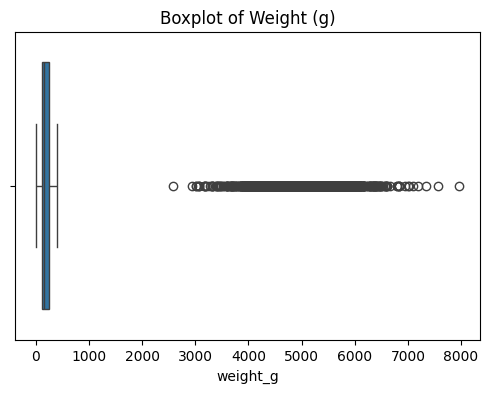

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["weight_g"])
plt.title("Boxplot of Weight (g)")
plt.show()

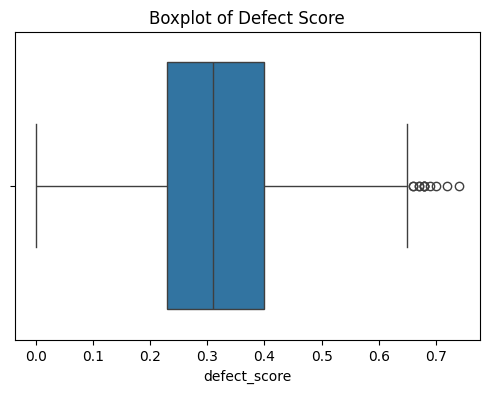

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["defect_score"])
plt.title("Boxplot of Defect Score")
plt.show()

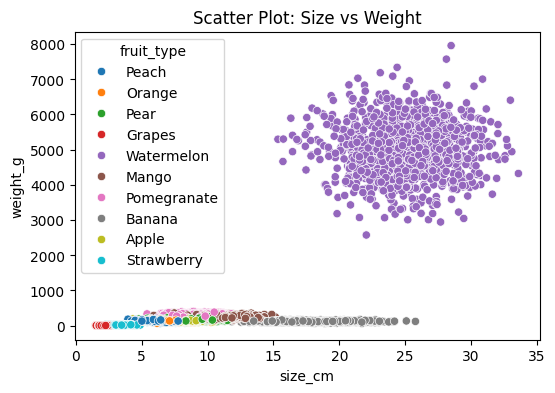

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="size_cm", y="weight_g", hue="fruit_type")
plt.title("Scatter Plot: Size vs Weight")
plt.show()

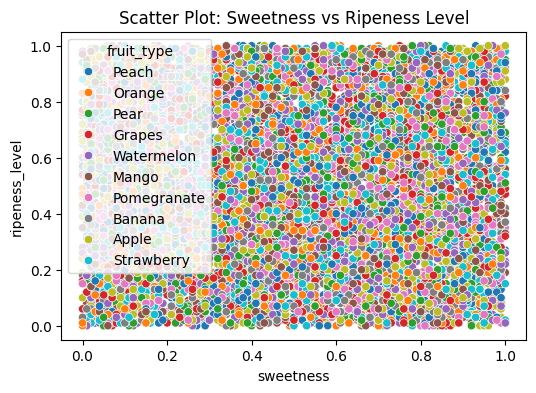

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="sweetness", y="ripeness_level", hue="fruit_type")
plt.title("Scatter Plot: Sweetness vs Ripeness Level")
plt.show()

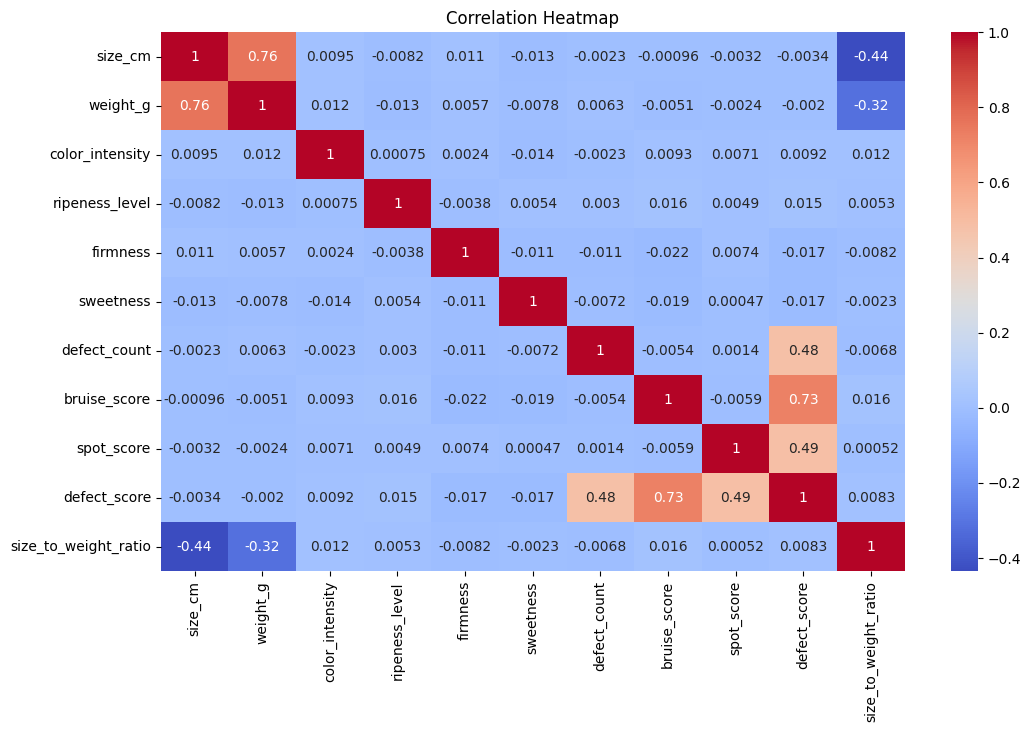

In [17]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

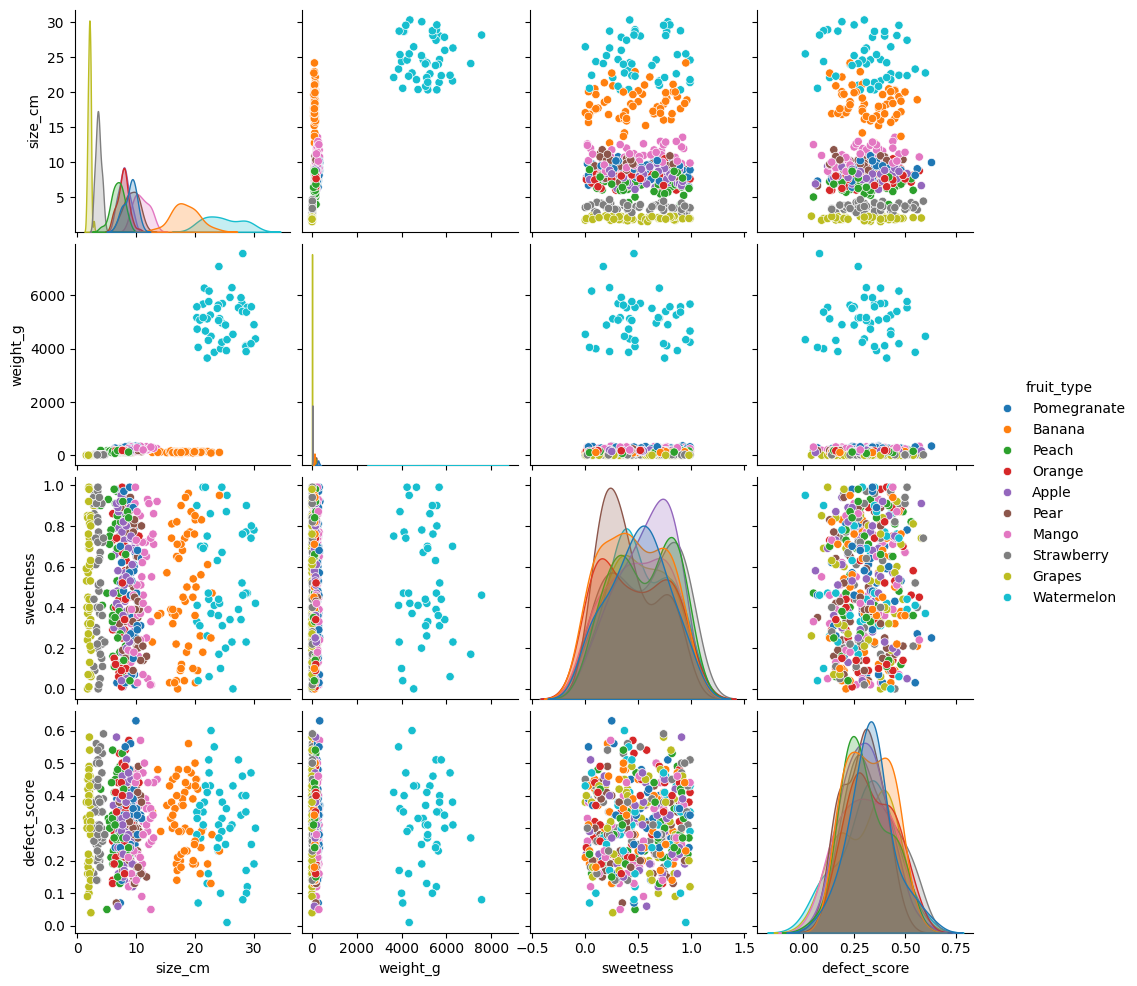

In [18]:
sample_df = df.sample(500, random_state=42)

sns.pairplot(sample_df, vars=["size_cm", "weight_g", "sweetness", "defect_score"], hue="fruit_type")
plt.show()

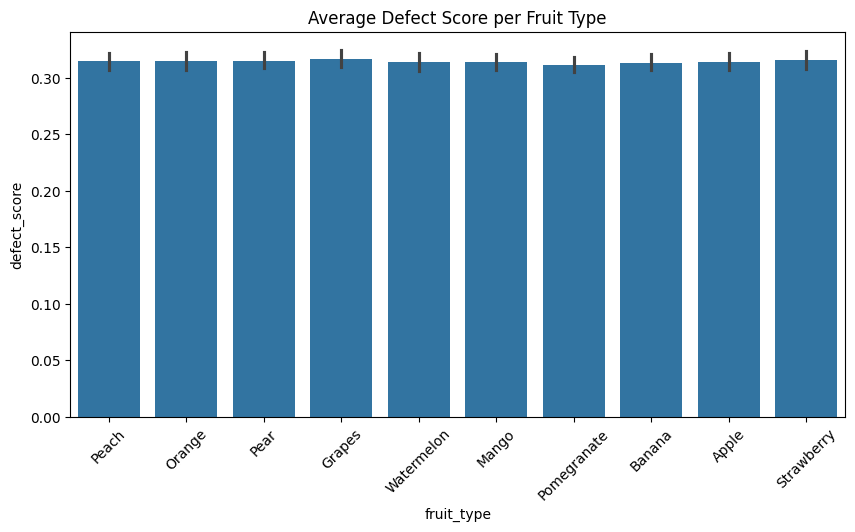

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="fruit_type", y="defect_score", estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Defect Score per Fruit Type")
plt.show()

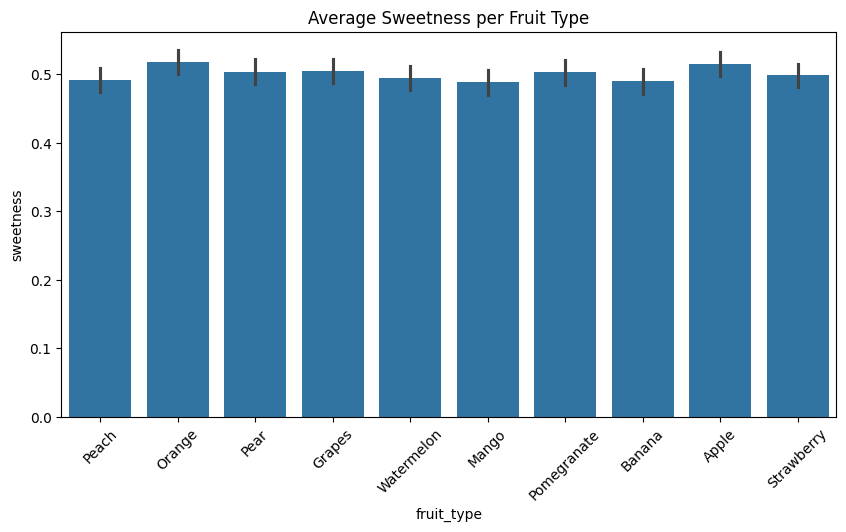

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="fruit_type", y="sweetness", estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Sweetness per Fruit Type")
plt.show()

**Relationship Analysis**

In [21]:
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top 10 strongest correlations:")
print(corr_pairs.head(10))

Top 10 strongest correlations:
size_cm         weight_g          0.763566
weight_g        size_cm           0.763566
bruise_score    defect_score      0.725132
defect_score    bruise_score      0.725132
                spot_score        0.486463
spot_score      defect_score      0.486463
defect_score    defect_count      0.479134
defect_count    defect_score      0.479134
ripeness_level  bruise_score      0.015856
bruise_score    ripeness_level    0.015856
dtype: float64


In [22]:
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("Highly correlated feature pairs (Multicollinearity risk):")
for pair in high_corr:
    print(pair)

Highly correlated feature pairs (Multicollinearity risk):


In [23]:
# Check correlation with defect_score (example relationship)
target_feature = "defect_score"

corr_with_defect = corr[target_feature].sort_values(ascending=False)

print("Correlation of all features with defect_score:")
print(corr_with_defect)

Correlation of all features with defect_score:
defect_score            1.000000
bruise_score            0.725132
spot_score              0.486463
defect_count            0.479134
ripeness_level          0.015453
color_intensity         0.009214
size_to_weight_ratio    0.008347
weight_g               -0.001999
size_cm                -0.003389
sweetness              -0.017363
firmness               -0.017381
Name: defect_score, dtype: float64


**Insight Genereation **

In [24]:
print("===== DATA-DRIVEN INSIGHTS =====")

print("\nInsight 1:")
print("Size and Weight show a strong positive correlation, meaning larger fruits tend to be heavier.")

print("\nInsight 2:")
print("Defect Score shows noticeable outliers (boxplot), indicating some fruits have unusually high defects.")

print("\nInsight 3:")
print("Sweetness and Ripeness level show a positive trend, meaning riper fruits tend to be sweeter.")

print("\nInsight 4:")
print("Some fruit types have higher average defect scores than others, meaning quality varies by fruit category.")

print("\nInsight 5:")
print("Some features show high multicollinearity (correlation > 0.85), which suggests redundancy and may require feature selection.")

===== DATA-DRIVEN INSIGHTS =====

Insight 1:
Size and Weight show a strong positive correlation, meaning larger fruits tend to be heavier.

Insight 2:
Defect Score shows noticeable outliers (boxplot), indicating some fruits have unusually high defects.

Insight 3:
Sweetness and Ripeness level show a positive trend, meaning riper fruits tend to be sweeter.

Insight 4:
Some fruit types have higher average defect scores than others, meaning quality varies by fruit category.

Insight 5:
Some features show high multicollinearity (correlation > 0.85), which suggests redundancy and may require feature selection.
